# Reproducing the dissertation figures

This notebook regenerates the data figures of the dissertation
*Hybrid LLM Deterministic Pipeline for Procurement Document Validation*
from the committed, aggregated result tables in `../results/`.

It is **fully offline**: no API key, no model call, and no raw case data are
required. Every number is read from a small JSON artefact that contains only
aggregate, anonymised results (per-design metrics, confusion counts, cost and
latency summaries). Run the cells top to bottom.

**The five designs.** The internal mode keys map to the design names used in
the dissertation as follows:

| key | design | enforcer |
|---|---|---|
| `none` | pure LLM (Mode A) | no |
| `deterministic` | post hoc (Mode B) | yes |
| `llm` | LLM-as-judge (Mode C) | no |
| `tool_use` | in generation (Mode D) | yes |
| `partition` | pre hoc (Mode E) | yes |

In [1]:
%matplotlib inline
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

RESULTS = Path("..") / "results"
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)


def load(name):
    return json.loads((RESULTS / name).read_text(encoding="utf-8"))


DESIGN = load("design_map.json")
ORDER = DESIGN["order"]                                  # canonical left-to-right order
LABEL = {k: DESIGN[k]["design"] for k in ORDER}          # key -> design name
ENFORCER = {k: DESIGN[k]["enforcer"] for k in ORDER}
SHORT = {k: LABEL[k].replace(" ", "\n") for k in ORDER}  # two-line labels for axes

# A consistent colour per design: enforcer-bearing designs in teal, free in orange.
COL = {k: ("#2a7f7f" if ENFORCER[k] else "#d2691e") for k in ORDER}

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.axisbelow": True, "savefig.bbox": "tight",
})
print("Loaded results for designs:", ", ".join(LABEL[k] for k in ORDER))

Loaded results for designs: pure LLM, post hoc, LLM-as-judge, in generation, pre hoc


## Figure 5.1 — Disposition metrics by design (synthetic vs buyer)
Accuracy, severity-weighted F1, quadratic-weighted kappa and Gwet's AC2, for
every design on both cohorts, with 95% bootstrap intervals. The enforcer-free
LLM-as-judge design collapses on the synthetic cohort.

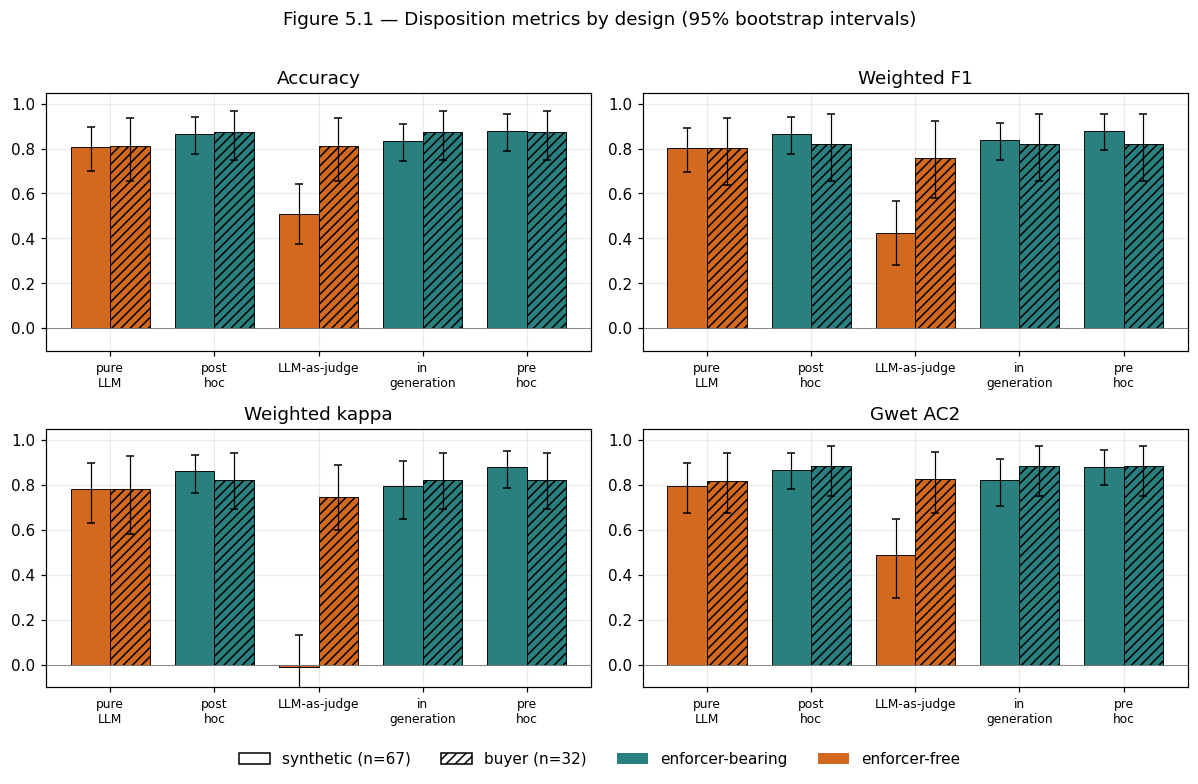

buyer accuracy: {'pure LLM': 0.812, 'post hoc': 0.875, 'LLM-as-judge': 0.812, 'in generation': 0.875, 'pre hoc': 0.875}


In [2]:
mb = load("metrics_buyer.json")["cohorts"]
ms = load("metrics_synthetic.json")

METRICS = [("accuracy", "Accuracy"), ("f1_weighted", "Weighted F1"),
           ("kappa_quadratic", "Weighted kappa"), ("gwet_ac2_linear", "Gwet AC2")]


def synth_metric(mode, key):
    m = ms[mode]["raw"]
    return m["metrics"][key], m["cis"][key]


def buyer_metric(mode, key):
    m = mb[mode]["production"]
    return m["metrics"][key], m["cis"][key]


fig, axes = plt.subplots(2, 2, figsize=(11, 7))
x = np.arange(len(ORDER))
w = 0.38
for ax, (key, title) in zip(axes.ravel(), METRICS):
    for off, getter, hatch, lbl in [(-w / 2, synth_metric, "", "synthetic (n=67)"),
                                    (+w / 2, buyer_metric, "////", "buyer (n=32)")]:
        vals, los, his = [], [], []
        for k in ORDER:
            v, (lo, hi) = getter(k, key)
            vals.append(v); los.append(v - lo); his.append(hi - v)
        ax.bar(x + off, vals, w, yerr=[los, his], capsize=2.5, hatch=hatch,
               color=[COL[k] for k in ORDER], edgecolor="black", linewidth=0.6,
               error_kw=dict(lw=0.8), label=lbl)
    ax.set_title(title); ax.set_xticks(x)
    ax.set_xticklabels([SHORT[k] for k in ORDER], fontsize=8)
    ax.set_ylim(-0.1, 1.05); ax.axhline(0, color="grey", lw=0.6)
handles = [Patch(facecolor="white", edgecolor="black", label="synthetic (n=67)"),
           Patch(facecolor="white", edgecolor="black", hatch="////", label="buyer (n=32)"),
           Patch(facecolor="#2a7f7f", label="enforcer-bearing"),
           Patch(facecolor="#d2691e", label="enforcer-free")]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Figure 5.1 — Disposition metrics by design (95% bootstrap intervals)")
fig.tight_layout(rect=(0, 0.03, 1, 0.97))
fig.savefig(FIGDIR / "fig_5_1_disposition_metrics.png")
plt.show()
print("buyer accuracy:", {LABEL[k]: round(buyer_metric(k, "accuracy")[0], 3) for k in ORDER})

## Figure 5.2 — Per-rule recall by design
Recall over the 41 evaluable single-rule mutant targets (synthetic) and the
106 buyer rule cells (R11 and R18 excluded). The two enforcer designs that
route every deterministic rule through the enforcer lead on the synthetic cohort.

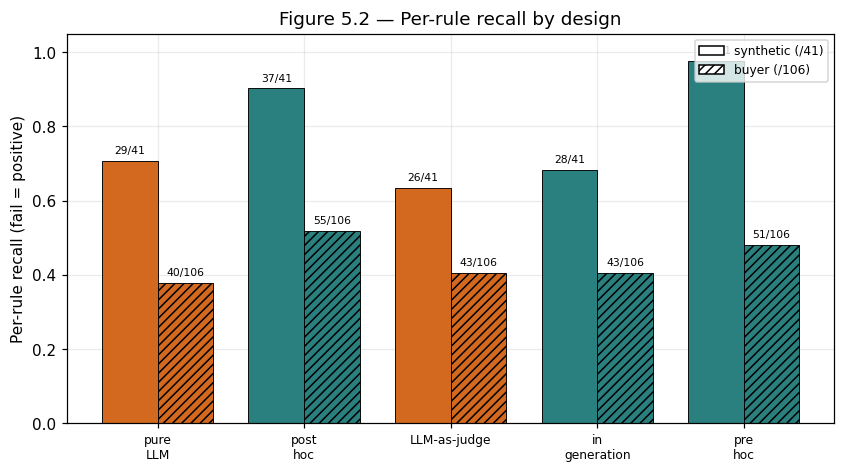

synthetic recall: {'pure LLM': '29/41', 'post hoc': '37/41', 'LLM-as-judge': '26/41', 'in generation': '28/41', 'pre hoc': '40/41'}


In [3]:
fig, ax = plt.subplots(figsize=(9, 4.6))
syn_rec = {k: ms[k]["rule_recall"] for k in ORDER}        # caught/total over 41
buy_rec = {k: mb[k]["rule_recall"] for k in ORDER}        # caught/expected over 106
for off, rec, hatch, lbl in [(-w / 2, syn_rec, "", "synthetic (/41)"),
                             (+w / 2, buy_rec, "////", "buyer (/106)")]:
    vals = [rec[k]["recall"] for k in ORDER]
    ax.bar(x + off, vals, w, hatch=hatch, color=[COL[k] for k in ORDER],
           edgecolor="black", linewidth=0.6, label=lbl)
    for xi, k in zip(x + off, ORDER):
        r = rec[k]
        caught = r.get("caught"); total = r.get("total", r.get("expected"))
        ax.text(xi, r["recall"] + 0.02, f"{caught}/{total}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([SHORT[k] for k in ORDER], fontsize=8)
ax.set_ylabel("Per-rule recall (fail = positive)"); ax.set_ylim(0, 1.05)
ax.legend(handles=[Patch(facecolor="white", edgecolor="black", label="synthetic (/41)"),
                   Patch(facecolor="white", edgecolor="black", hatch="////", label="buyer (/106)")],
          loc="upper right", fontsize=8)
ax.set_title("Figure 5.2 — Per-rule recall by design")
fig.savefig(FIGDIR / "fig_5_2_rule_recall.png")
plt.show()
print("synthetic recall:", {LABEL[k]: f'{syn_rec[k]["caught"]}/{syn_rec[k]["total"]}' for k in ORDER})

## Figure 5.3 — Paired effect sizes (Cohen's h) against the pre hoc reference
Each contrast compares a design against the recommended pre hoc design. Only
the synthetic LLM-as-judge contrast clears the large-effect band and survives
the Holm correction.

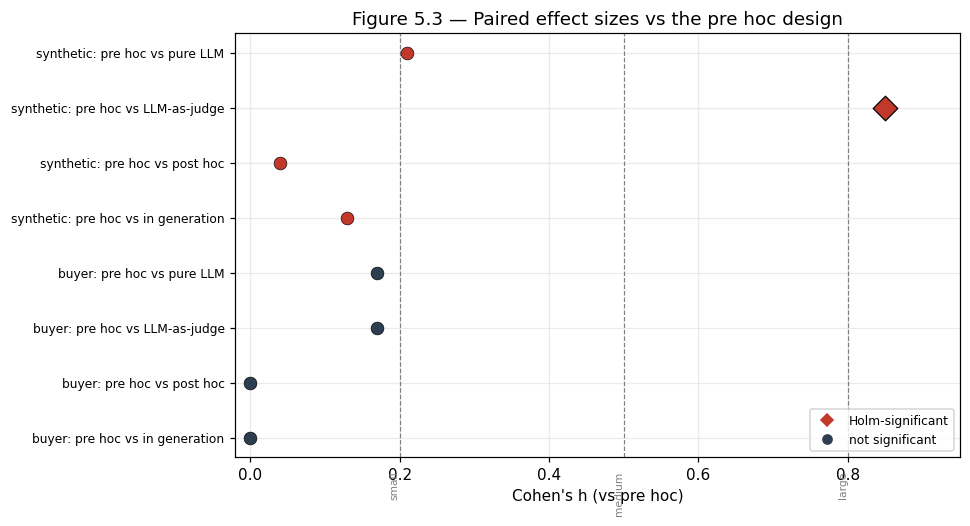

In [4]:
con = load("contrasts.json")
rows = con["contrasts"]
fig, ax = plt.subplots(figsize=(8.5, 5))
ypos = np.arange(len(rows))
for i, r in enumerate(rows):
    sig = r["mcnemar_p_holm"] < 0.05
    c = "#c0392b" if r["sample"] == "synthetic" else "#2c3e50"
    ax.scatter(r["cohen_h"], i, s=130 if sig else 70, color=c,
               marker="D" if sig else "o", zorder=3,
               edgecolor="black", linewidth=0.8 if sig else 0.4)
for b, lbl in [(0.2, "small"), (0.5, "medium"), (0.8, "large")]:
    ax.axvline(b, color="grey", ls="--", lw=0.8)
    ax.text(b, len(rows) - 0.4, lbl, rotation=90, va="top", ha="right", fontsize=7, color="grey")
ax.set_yticks(ypos)
ax.set_yticklabels([f'{r["sample"]}: pre hoc vs {LABEL[r["other"]]}' for r in rows], fontsize=8)
ax.set_xlabel("Cohen's h (vs pre hoc)"); ax.set_xlim(-0.02, 0.95)
ax.invert_yaxis()
ax.legend(handles=[plt.Line2D([], [], marker="D", ls="", color="#c0392b", label="Holm-significant"),
                   plt.Line2D([], [], marker="o", ls="", color="#2c3e50", label="not significant")],
          loc="lower right", fontsize=8)
ax.set_title("Figure 5.3 — Paired effect sizes vs the pre hoc design")
fig.savefig(FIGDIR / "fig_5_3_effect_sizes.png")
plt.show()

## Figure 5.4 / I.1 — Cross-model enforcer gap (buyer cohort)
Disposition accuracy of the five designs under the primary model
(gpt-5.4-mini) and a second model from a different family (Mistral-Large-3).
The enforcer-vs-free gap survives the model swap and in fact widens.

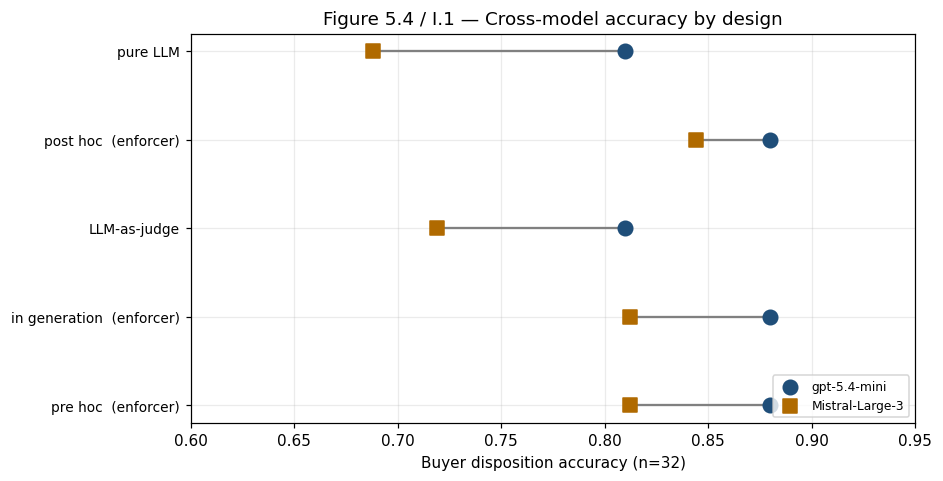

gap gpt: 0.07 | gap mistral: 0.12


In [5]:
cm = load("cross_model_buyer.json")
acc = cm["accuracy"]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for i, k in enumerate(ORDER):
    g, m = acc[k]
    ax.plot([g, m], [i, i], color="grey", lw=1.5, zorder=1)
    ax.scatter(g, i, s=90, color="#1f4e79", zorder=3, label="gpt-5.4-mini" if i == 0 else "")
    ax.scatter(m, i, s=90, color="#b06a00", marker="s", zorder=3, label="Mistral-Large-3" if i == 0 else "")
ax.set_yticks(range(len(ORDER)))
ax.set_yticklabels([f"{LABEL[k]}{'  (enforcer)' if ENFORCER[k] else ''}" for k in ORDER], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel("Buyer disposition accuracy (n=32)"); ax.set_xlim(0.6, 0.95)
ax.legend(loc="lower right", fontsize=8)
ax.set_title("Figure 5.4 / I.1 — Cross-model accuracy by design")
fig.savefig(FIGDIR / "fig_5_4_cross_model.png")
plt.show()
print("gap gpt:", cm["enforcer_gap"]["gpt-5.4-mini"]["gap"], "| gap mistral:", cm["enforcer_gap"]["Mistral-Large-3"]["gap"])

## Figure 5.5 — The three enforcer positions
Post hoc, in generation and pre hoc tie on accuracy, and separate only on the
operational axes: cost, latency and reproducibility, where pre hoc leads.

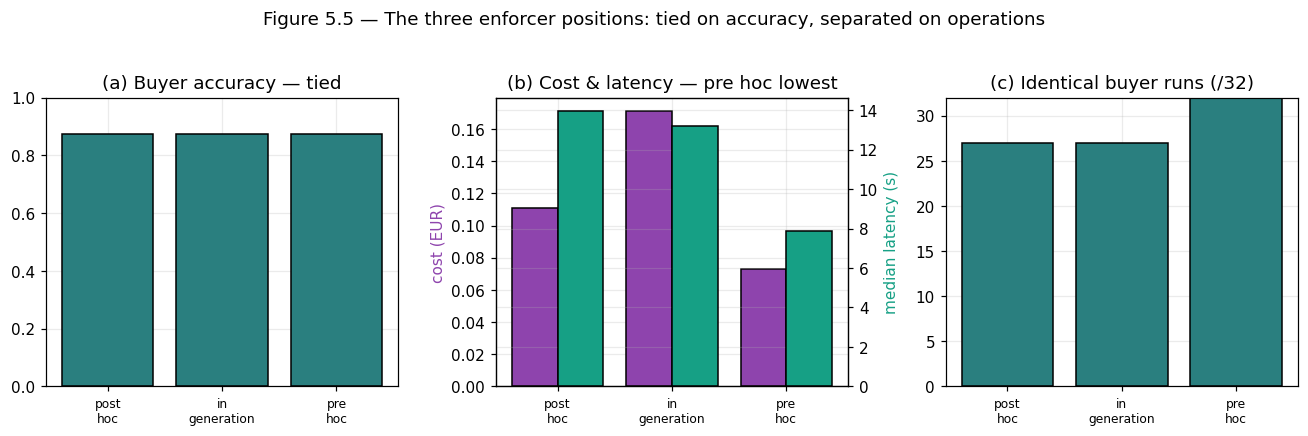

In [6]:
op = load("operational.json")
rep = load("reproducibility.json")["designs"]
POS = ["deterministic", "tool_use", "partition"]
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
# (a) accuracy — all tie at 0.88
axs[0].bar([SHORT[k] for k in POS], [mb[k]["production"]["metrics"]["accuracy"] for k in POS],
           color=[COL[k] for k in POS], edgecolor="black")
axs[0].set_ylim(0, 1); axs[0].set_title("(a) Buyer accuracy — tied")
axs[0].tick_params(axis="x", labelsize=8)
# (b) cost (EUR) and latency (median s) — twin axis
xb = np.arange(len(POS))
cost = [op["cost_eur"][k][0] for k in POS]
lat = [op["latency_seconds"][k][2] for k in POS]
axs[1].bar(xb - 0.2, cost, 0.4, color="#8e44ad", edgecolor="black", label="cost (EUR)")
ax2 = axs[1].twinx()
ax2.bar(xb + 0.2, lat, 0.4, color="#16a085", edgecolor="black", label="latency (s)")
axs[1].set_xticks(xb); axs[1].set_xticklabels([SHORT[k] for k in POS], fontsize=8)
axs[1].set_ylabel("cost (EUR)", color="#8e44ad"); ax2.set_ylabel("median latency (s)", color="#16a085")
axs[1].set_title("(b) Cost & latency — pre hoc lowest")
# (c) reproducibility — buyer identical runs /32
axs[2].bar([SHORT[k] for k in POS], [rep[k]["buyer_identical"] for k in POS],
           color=[COL[k] for k in POS], edgecolor="black")
axs[2].set_ylim(0, 32); axs[2].set_title("(c) Identical buyer runs (/32)")
axs[2].tick_params(axis="x", labelsize=8)
fig.suptitle("Figure 5.5 — The three enforcer positions: tied on accuracy, separated on operations")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIGDIR / "fig_5_5_enforcer_positions.png")
plt.show()

## Figure 5.6 — Disposition confusion matrices
Rows are the consensus ground truth, columns the pipeline disposition. Above
the diagonal is over-rejection (tolerable), below is under-rejection (unsafe).
Buyer cohort on top, synthetic cohort on the bottom.

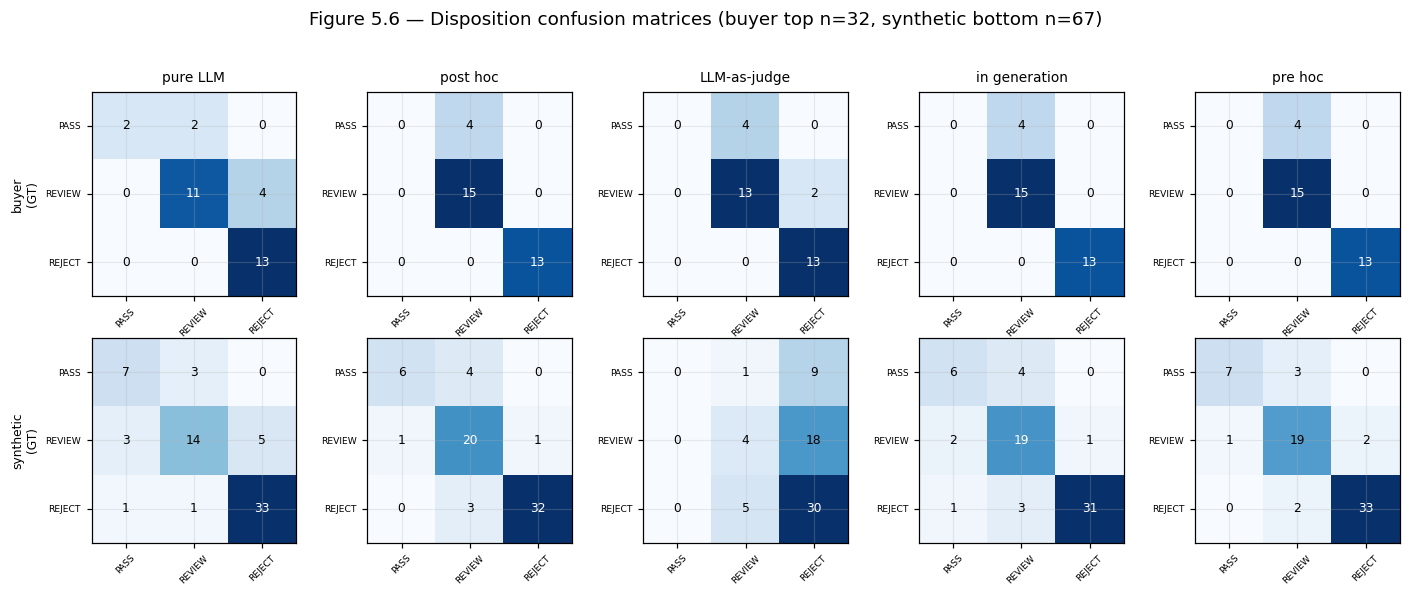

In [7]:
conf = load("confusion.json")
labs = conf["labels"]
fig, axs = plt.subplots(2, len(ORDER), figsize=(13, 5.4))
for col, k in enumerate(ORDER):
    for row, cohort in enumerate(["buyer", "synthetic"]):
        ax = axs[row, col]
        M = np.array(conf[cohort][k])
        ax.imshow(M, cmap="Blues", vmin=0, vmax=M.max())
        for i in range(3):
            for j in range(3):
                ax.text(j, i, M[i, j], ha="center", va="center", fontsize=8,
                        color="white" if M[i, j] > M.max() * 0.6 else "black")
        ax.set_xticks(range(3)); ax.set_yticks(range(3))
        ax.set_xticklabels(labs, fontsize=6, rotation=45); ax.set_yticklabels(labs, fontsize=6)
        if row == 0:
            ax.set_title(LABEL[k], fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{cohort}\n(GT)", fontsize=8)
fig.suptitle("Figure 5.6 — Disposition confusion matrices (buyer top n=32, synthetic bottom n=67)")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIGDIR / "fig_5_6_confusion.png")
plt.show()

## Figure F.1 — Latency per ASN by design
Box = inter-quartile range, line = median, whiskers to min and p90, points at
p95 and max (provider-delay outliers). Drawn from the committed summary
statistics over the 28 production cases. Pre hoc is the tightest and fastest.

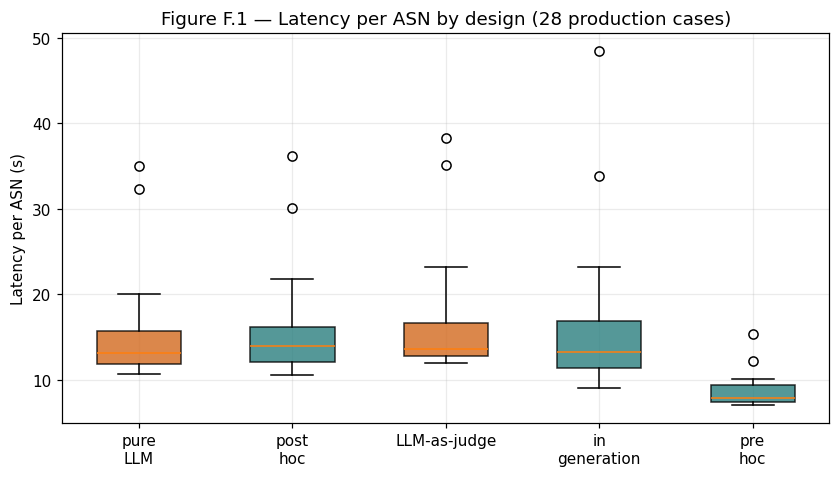

median latency: {'pure LLM': 13.14, 'post hoc': 13.94, 'LLM-as-judge': 13.67, 'in generation': 13.22, 'pre hoc': 7.89}


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.6))
stats = []
for k in ORDER:
    mn, q1, med, q3, p90, p95, mx, sd = op["latency_seconds"][k]
    stats.append(dict(label=SHORT[k], med=med, q1=q1, q3=q3, whislo=mn, whishi=p90, fliers=[p95, mx]))
bp = ax.bxp(stats, showfliers=True, patch_artist=True, widths=0.55)
for patch, k in zip(bp["boxes"], ORDER):
    patch.set_facecolor(COL[k]); patch.set_alpha(0.8)
ax.set_ylabel("Latency per ASN (s)")
ax.set_title("Figure F.1 — Latency per ASN by design (28 production cases)")
fig.savefig(FIGDIR / "fig_F_1_latency.png")
plt.show()
print("median latency:", {LABEL[k]: op["latency_seconds"][k][2] for k in ORDER})

## Figure F.2 — Cost / accuracy trade-off (Pareto)
Mean cost per ASN (EUR) against buyer disposition accuracy; marker area scales
with median latency. Pre hoc sits at the favourable corner: lowest cost,
lowest latency, top accuracy.

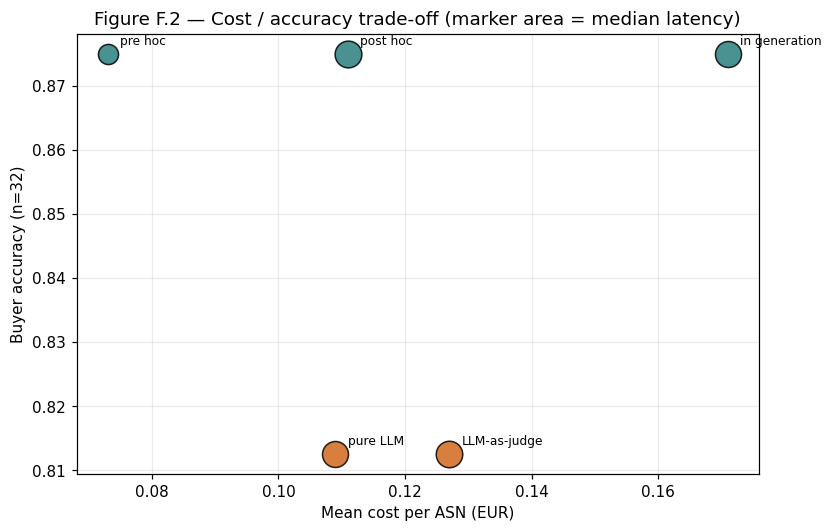

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.2))
for k in ORDER:
    cost = op["cost_eur"][k][0]
    a = mb[k]["production"]["metrics"]["accuracy"]
    lat = op["latency_seconds"][k][2]
    ax.scatter(cost, a, s=lat * 22, color=COL[k], edgecolor="black", alpha=0.85, zorder=3)
    ax.annotate(LABEL[k], (cost, a), textcoords="offset points", xytext=(8, 6), fontsize=8)
ax.set_xlabel("Mean cost per ASN (EUR)"); ax.set_ylabel("Buyer accuracy (n=32)")
ax.set_title("Figure F.2 — Cost / accuracy trade-off (marker area = median latency)")
fig.savefig(FIGDIR / "fig_F_2_pareto.png")
plt.show()

## Figure I.2 — Synthetic cohort under the second model (Mistral-Large-3)
Disposition accuracy, single-rule recall over the 41 evaluable targets, and
failed PASS controls (of 9 single-rule clean cases). The LLM-as-judge collapse
and the enforcer lead both replicate across model families.

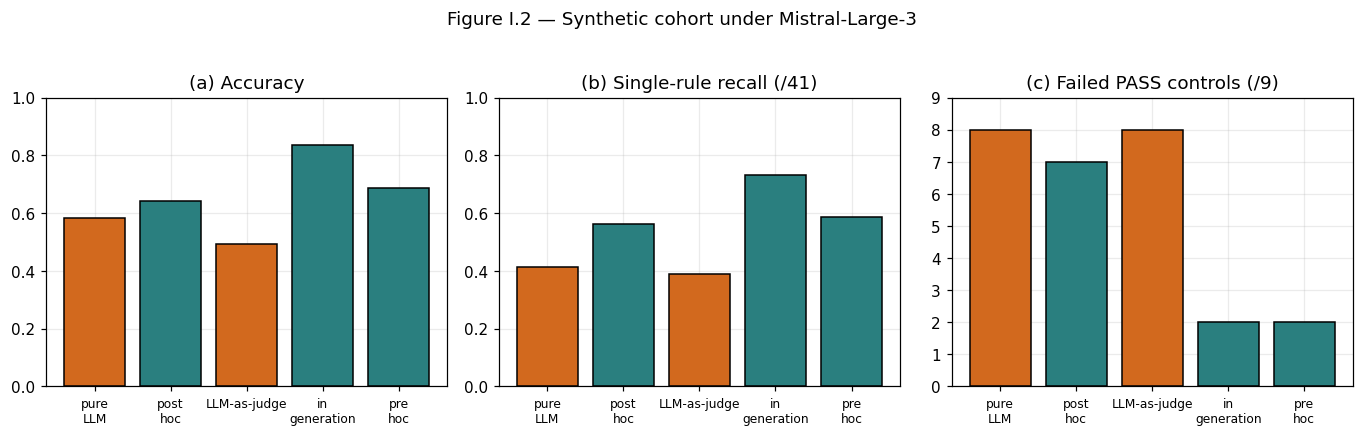

In [10]:
cms = load("cross_model_synthetic.json")["summary"]
fig, axs = plt.subplots(1, 3, figsize=(12.5, 4))
axs[0].bar([SHORT[k] for k in ORDER], [cms[k]["accuracy"] for k in ORDER],
           color=[COL[k] for k in ORDER], edgecolor="black")
axs[0].set_ylim(0, 1); axs[0].set_title("(a) Accuracy")
axs[1].bar([SHORT[k] for k in ORDER], [cms[k]["recall"] for k in ORDER],
           color=[COL[k] for k in ORDER], edgecolor="black")
axs[1].set_ylim(0, 1); axs[1].set_title("(b) Single-rule recall (/41)")
axs[2].bar([SHORT[k] for k in ORDER], [cms[k]["pass_control_fails"][0] for k in ORDER],
           color=[COL[k] for k in ORDER], edgecolor="black")
axs[2].set_ylim(0, 9); axs[2].set_title("(c) Failed PASS controls (/9)")
for a in axs:
    a.tick_params(axis="x", labelsize=8)
fig.suptitle("Figure I.2 — Synthetic cohort under Mistral-Large-3")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIGDIR / "fig_I_2_cross_model_synthetic.png")
plt.show()

## Figure (RQ3) — Supplier-conditioning ablation
Disposition accuracy across the retrieval-off, leave-one-out and placebo arms
on the 18 production cases. The effect is null: accuracy does not move once the
enforcer settles the computable rules.

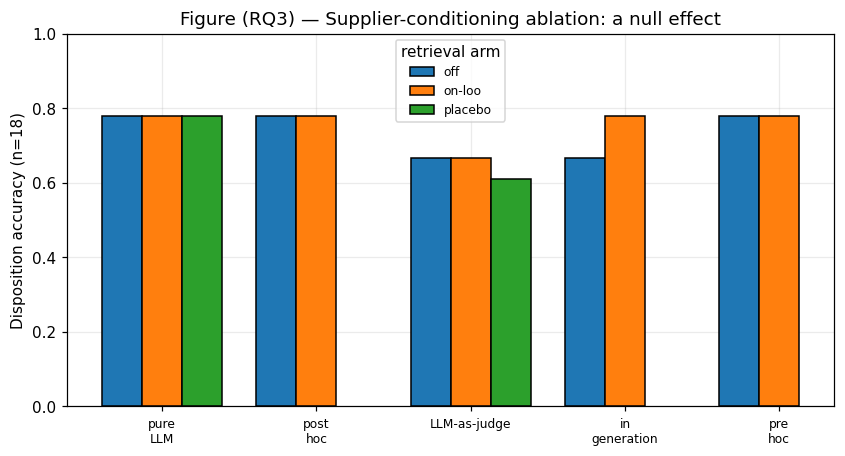

In [11]:
ab = load("supplier_ablation.json")["accuracy"]
arms = ["off", "on_loo", "placebo"]
fig, ax = plt.subplots(figsize=(9, 4.4))
xa = np.arange(len(ORDER)); wd = 0.26
for j, arm in enumerate(arms):
    vals = [ab[k].get(arm) for k in ORDER]
    vals = [np.nan if v is None else v for v in vals]
    ax.bar(xa + (j - 1) * wd, vals, wd, edgecolor="black", label=arm.replace("_", "-"))
ax.set_xticks(xa); ax.set_xticklabels([SHORT[k] for k in ORDER], fontsize=8)
ax.set_ylim(0, 1); ax.set_ylabel("Disposition accuracy (n=18)")
ax.legend(title="retrieval arm", fontsize=8)
ax.set_title("Figure (RQ3) — Supplier-conditioning ablation: a null effect")
fig.savefig(FIGDIR / "fig_rq3_supplier_ablation.png")
plt.show()

## Spot-check against the dissertation
These printed values should match the thesis text and tables.

In [12]:
print("Buyer accuracy  (expect pure LLM 0.81, post hoc/in gen/pre hoc 0.88, LLM-as-judge 0.81):")
for k in ORDER:
    print(f"  {LABEL[k]:14s} {mb[k]['production']['metrics']['accuracy']:.3f}")
print("\nPre hoc cost (expect EUR 0.073):", op["cost_eur"]["partition"][0])
print("Pre hoc median latency (expect 7.89 s):", op["latency_seconds"]["partition"][2])
print("\nCross-model buyer accuracy (expect 0.69/0.84/0.72/0.81/0.81 order none/det/llm/tool/part):")
print("  ", [cm["accuracy"][k][1] for k in ORDER])
print("\nSynthetic LLM-as-judge accuracy (expect ~0.51):", ms["llm"]["raw"]["metrics"]["accuracy"])

Buyer accuracy  (expect pure LLM 0.81, post hoc/in gen/pre hoc 0.88, LLM-as-judge 0.81):
  pure LLM       0.812
  post hoc       0.875
  LLM-as-judge   0.812
  in generation  0.875
  pre hoc        0.875

Pre hoc cost (expect EUR 0.073): 0.073
Pre hoc median latency (expect 7.89 s): 7.89

Cross-model buyer accuracy (expect 0.69/0.84/0.72/0.81/0.81 order none/det/llm/tool/part):
   [0.688, 0.844, 0.719, 0.812, 0.812]

Synthetic LLM-as-judge accuracy (expect ~0.51): 0.5074626865671642
